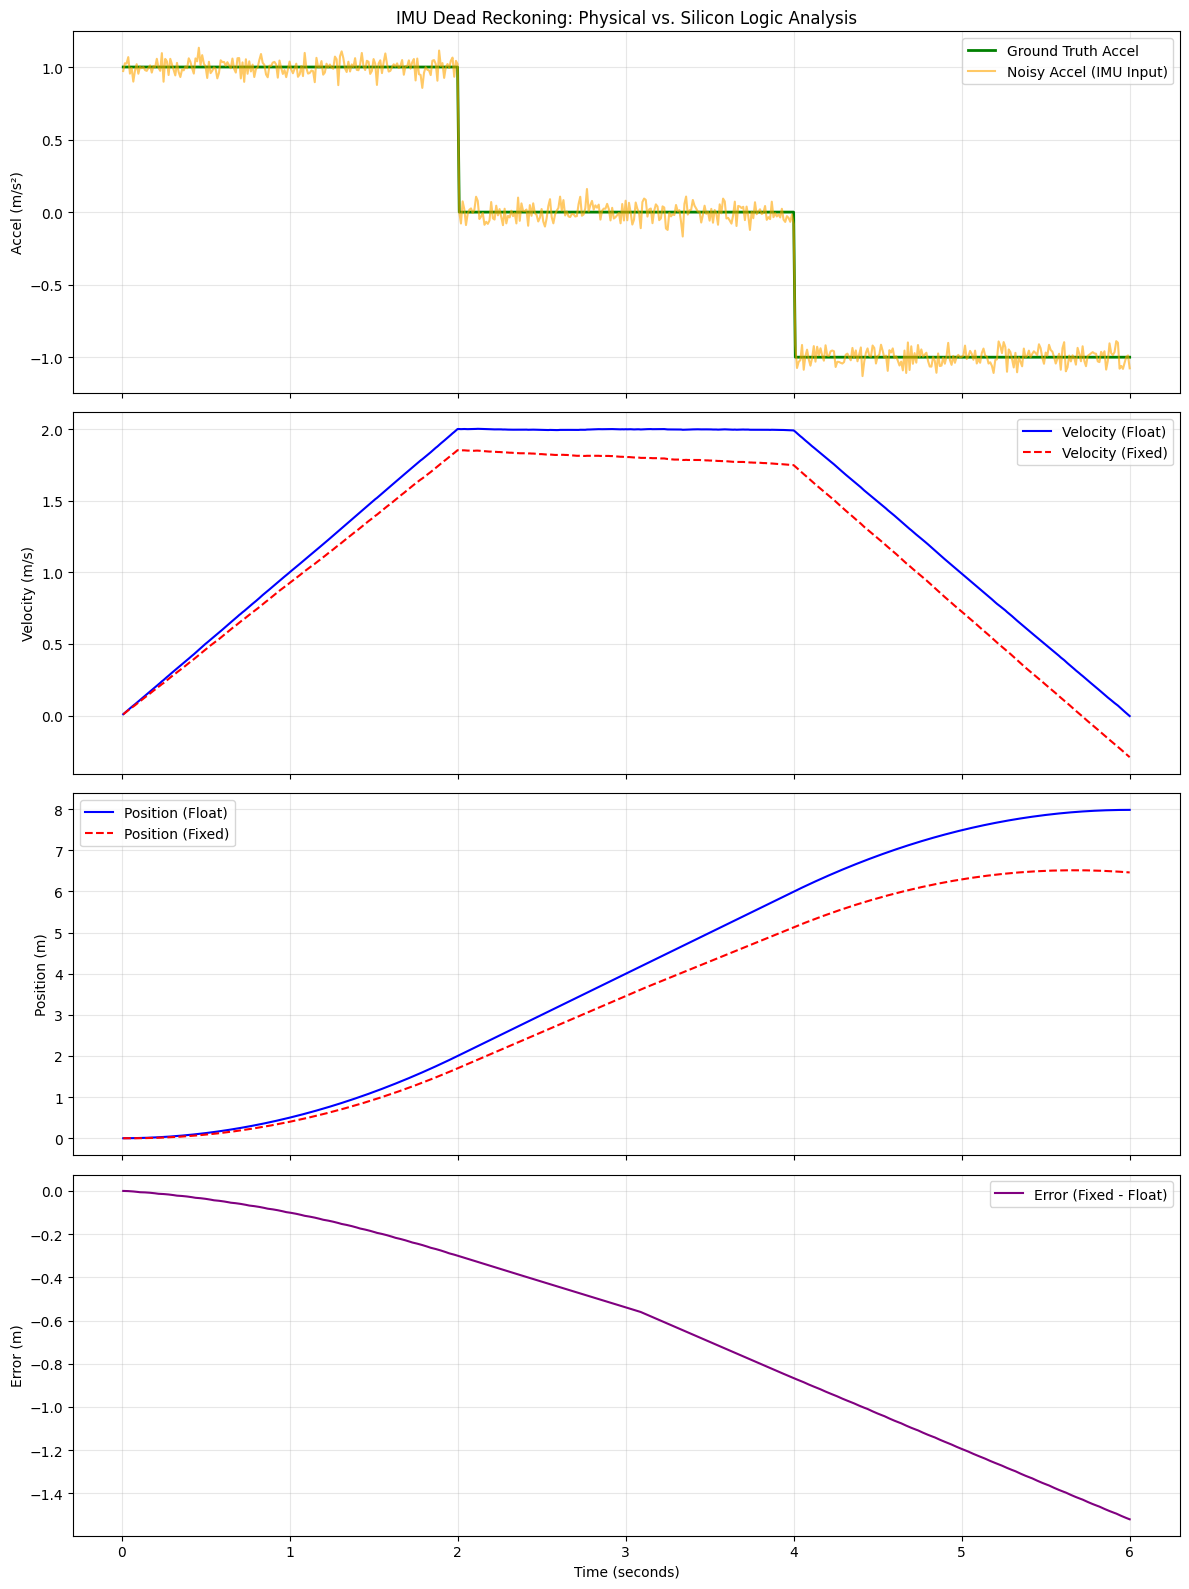

Total Trajectory Time: 6.0 seconds
Final Quantization Error: -1.5205 meters


In [4]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Load the results from the C++ execution
df = pd.read_csv('/content/drive/MyDrive/MA/IMU_SLAM_FPGA/imu_dead_reckoning_results.csv')

# 2. Setup the visualization grid
fig, axes = plt.subplots(4, 1, figsize=(12, 16), sharex=True)

# Plot 1: Acceleration Comparison
# Shows the ground truth vs the noisy input the algorithm actually processed
axes[0].plot(df['time_s'], df['accel_true'], label='Ground Truth Accel', color='green', linewidth=2)
axes[0].plot(df['time_s'], df['accel_noisy'], label='Noisy Accel (IMU Input)', color='orange', alpha=0.6)
axes[0].set_ylabel('Accel (m/s²)')
axes[0].set_title('IMU Dead Reckoning: Physical vs. Silicon Logic Analysis')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: Velocity Comparison
# Compares high-precision floats to the bit-shifted integer logic
axes[1].plot(df['time_s'], df['vel_float'], label='Velocity (Float)', color='blue')
axes[1].plot(df['time_s'], df['vel_fixed'], label='Velocity (Fixed)', color='red', linestyle='--')
axes[1].set_ylabel('Velocity (m/s)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Plot 3: Position Comparison
# This highlights the "drift" gap between software and hardware implementation
axes[2].plot(df['time_s'], df['pos_float'], label='Position (Float)', color='blue')
axes[2].plot(df['time_s'], df['pos_fixed'], label='Position (Fixed)', color='red', linestyle='--')
axes[2].set_ylabel('Position (m)')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

# Plot 4: Quantization Error
# This is the 'Master's Thesis' part: analyzing exactly how much precision was lost
axes[3].plot(df['time_s'], df['pos_error'], label='Error (Fixed - Float)', color='purple')
axes[3].set_ylabel('Error (m)')
axes[3].set_xlabel('Time (seconds)')
axes[3].legend()
axes[3].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Quick summary statistics
final_error = df['pos_error'].iloc[-1]
print(f"Total Trajectory Time: {df['time_s'].iloc[-1]} seconds")
print(f"Final Quantization Error: {final_error:.4f} meters")